# Churn Analysis

## SQL

In [6]:
import sqlite3

In [7]:
conn = sqlite3.connect("customer_churn.db")
cursor = conn.cursor()

In [8]:
cursor.execute("""SELECT name 
FROM sqlite_master
WHERE type = 'table'""")

In [9]:
tables=cursor.fetchall()
tables

[('db_customer',), ('db_subscription',), ('db_support',)]

In [10]:
cursor.execute("PRAGMA table_info(db_customer);")
cursor.fetchall()

[(0, 'customerid', 'TEXT', 0, None, 0),
 (1, 'name', 'TEXT', 0, None, 0),
 (2, 'country', 'TEXT', 0, None, 0),
 (3, 'state', 'TEXT', 0, None, 0),
 (4, 'gender', 'TEXT', 0, None, 0),
 (5, 'dob', 'TIMESTAMP', 0, None, 0),
 (6, 'interests', 'TEXT', 0, None, 0),
 (7, 'pincode', 'REAL', 0, None, 0)]

In [11]:
cursor.execute("PRAGMA table_info(db_subscription)")
cursor.fetchall()

[(0, 'customerid', 'TEXT', 0, None, 0),
 (1, 'subscription_start_date', 'TEXT', 0, None, 0),
 (2, 'subscription_type', 'TEXT', 0, None, 0),
 (3, 'renewal_date', 'TEXT', 0, None, 0),
 (4, 'plan_type', 'TEXT', 0, None, 0),
 (5, 'contract_type', 'TEXT', 0, None, 0),
 (6, 'cancellation_date', 'TEXT', 0, None, 0),
 (7, 'cancellation_reason', 'TEXT', 0, None, 0),
 (8, 'monthly_charges', 'REAL', 0, None, 0),
 (9, 'cltv', 'INTEGER', 0, None, 0),
 (10, 'churn_score', 'INTEGER', 0, None, 0)]

In [12]:
cursor.execute("PRAGMA table_info(db_support)")
cursor.fetchall()

[(0, 'customerid', 'TEXT', 0, None, 0),
 (1, 'complaint_date', 'TIMESTAMP', 0, None, 0),
 (2, 'escalations', 'TEXT', 0, None, 0),
 (3, 'csat_score', 'INTEGER', 0, None, 0),
 (4, 'col_1', 'REAL', 0, None, 0),
 (5, 'comment', 'TEXT', 0, None, 0)]

In [13]:
cursor.execute("""SELECT COUNT(*)
FROM db_customer""")
cursor.fetchall()

[(21,)]

In [14]:
cursor.execute(""" SELECT COUNT(*) 
FROM db_subscription
WHERE cancellation_date IS NOT NULL""")
cursor.fetchall()

[(6,)]

In [15]:
cursor.execute("""SELECT cancellation_reason FROM db_subscription WHERE cancellation_date IS NOT NULL""")
cursor.fetchall()

[('Switched to competitor',),
 ('Too expensive',),
 ('Not enough content',),
 ('Poor streaming quality',),
 ('Switched to competitor',),
 ('Forgot to cancel trial',)]

In [16]:
cursor.execute("""SELECT plan_type,COUNT(*) FROM db_subscription WHERE cancellation_date IS NOT NULL GROUP BY plan_type""")
cursor.fetchall()

[('Basic', 3), ('Premium', 1), ('Standard', 2)]

In [17]:
cursor.execute("""SELECT plan_type,COUNT(*) FROM db_subscription GROUP BY plan_type""")
cursor.fetchall()

[('Basic', 5), ('Premium', 7), ('Standard', 9)]

In [18]:
cursor.execute("""SELECT contract_type, COUNT(*) FROM db_subscription GROUP BY contract_type""")
cursor.fetchall()

[('Annual', 12), ('Monthly', 9)]

In [19]:
cursor.execute("""SELECT contract_type,COUNT(*) FROM db_subscription WHERE cancellation_date IS NOT NULL GROUP BY contract_type""")
cursor.fetchall()

[('Annual', 1), ('Monthly', 5)]

In [20]:
cursor.execute("""SELECT plan_type,contract_type,COUNT(*) FROM db_subscription WHERE cancellation_date IS NOT NULL GROUP BY plan_type,contract_type""")
cursor.fetchall()

[('Basic', 'Monthly', 3), ('Premium', 'Annual', 1), ('Standard', 'Monthly', 2)]

In [21]:
cursor.execute("""SELECT customerid, COUNT(*) FROM db_support GROUP BY customerid""")
cursor.fetchall()

[('0003-MKNFE', 2),
 ('0013-EXCHZ', 1),
 ('0013-MHZWF', 1),
 ('0013-SMEOE', 1),
 ('0017-IUDMW', 1),
 ('0019-EFAEP', 1),
 ('0022-TCJCI', 2)]

In [22]:
cursor.execute(""" SELECT COUNT(*) FROM db_support""")
cursor.fetchall()

[(9,)]

In [23]:
cursor.execute( """ SELECT db_support.customerid, db_subscription.cancellation_date FROM db_support JOIN db_subscription ON db_support.customerid  = db_support.customerid """)
cursor.fetchall()

[('0003-MKNFE', None),
 ('0003-MKNFE', '2024-09-10'),
 ('0003-MKNFE', None),
 ('0003-MKNFE', None),
 ('0003-MKNFE', '2024-02-28'),
 ('0003-MKNFE', None),
 ('0003-MKNFE', '2024-11-15'),
 ('0003-MKNFE', None),
 ('0003-MKNFE', None),
 ('0003-MKNFE', None),
 ('0003-MKNFE', None),
 ('0003-MKNFE', '2024-05-01'),
 ('0003-MKNFE', None),
 ('0003-MKNFE', '2024-10-31'),
 ('0003-MKNFE', None),
 ('0003-MKNFE', None),
 ('0003-MKNFE', None),
 ('0003-MKNFE', None),
 ('0003-MKNFE', '2024-09-14'),
 ('0003-MKNFE', None),
 ('0003-MKNFE', None),
 ('0003-MKNFE', None),
 ('0003-MKNFE', '2024-09-10'),
 ('0003-MKNFE', None),
 ('0003-MKNFE', None),
 ('0003-MKNFE', '2024-02-28'),
 ('0003-MKNFE', None),
 ('0003-MKNFE', '2024-11-15'),
 ('0003-MKNFE', None),
 ('0003-MKNFE', None),
 ('0003-MKNFE', None),
 ('0003-MKNFE', None),
 ('0003-MKNFE', '2024-05-01'),
 ('0003-MKNFE', None),
 ('0003-MKNFE', '2024-10-31'),
 ('0003-MKNFE', None),
 ('0003-MKNFE', None),
 ('0003-MKNFE', None),
 ('0003-MKNFE', None),
 ('0003-MKNFE',

Does each customer have multiple subscription records?

In [24]:
cursor.execute("""SELECT customerid,COUNT(*) FROM db_subscription GROUP BY customerid""")
cursor.fetchall()

[('0002-ORFBO', 1),
 ('0003-MKNFE', 1),
 ('0004-TLHLJ', 1),
 ('0011-IGKFF', 1),
 ('0013-EXCHZ', 1),
 ('0013-MHZWF', 1),
 ('0013-SMEOE', 1),
 ('0014-BMAQU', 1),
 ('0015-UOCOJ', 1),
 ('0016-QLJIS', 1),
 ('0017-DINOC', 1),
 ('0017-IUDMW', 1),
 ('0018-NYROU', 1),
 ('0019-EFAEP', 1),
 ('0019-GFNTW', 1),
 ('0020-INWCK', 1),
 ('0020-JDNXP', 1),
 ('0021-IKXGC', 1),
 ('0022-TCJCI', 1),
 ('0023-HGHWL', 1),
 ('0023-UYUPN', 1)]

In [25]:
cursor.execute("""SELECT * FROM db_support""")
cursor.fetchall()

[('0003-MKNFE', '2024-08-28 00:00:00', 'N', 60, None, 'service issue'),
 ('0003-MKNFE', '2024-08-28 00:00:00', 'Y', 10, None, 'demaned refund'),
 ('0013-EXCHZ', '2024-01-20 00:00:00', 'Y', 20, None, None),
 ('0013-MHZWF', '2025-03-18 00:00:00', 'N', 90, None, 'guidance to renew'),
 ('0013-SMEOE', '2024-11-01 00:00:00', 'N', 30, None, None),
 ('0017-IUDMW', '2024-04-10 00:00:00', 'Y', 25, None, None),
 ('0019-EFAEP', '2024-09-27 00:00:00', 'Y', 30, None, None),
 ('0022-TCJCI', '2024-09-13 00:00:00', 'Y', 10, None, None),
 ('0022-TCJCI', '2024-09-14 00:00:00', 'N', 90, None, 'received refund')]

Of the customers who contacted support, which ones churned?


In [26]:
cursor.execute(""" SELECT db_support.customerid,db_support.csat_score,db_support.escalations,db_subscription.cancellation_date FROM db_support JOIN db_subscription ON db_support.customerid = db_subscription.customerid""")
cursor.fetchall()

[('0003-MKNFE', 60, 'N', '2024-09-10'),
 ('0003-MKNFE', 10, 'Y', '2024-09-10'),
 ('0013-EXCHZ', 20, 'Y', '2024-02-28'),
 ('0013-MHZWF', 90, 'N', None),
 ('0013-SMEOE', 30, 'N', '2024-11-15'),
 ('0017-IUDMW', 25, 'Y', '2024-05-01'),
 ('0019-EFAEP', 30, 'Y', '2024-10-31'),
 ('0022-TCJCI', 10, 'Y', '2024-09-14'),
 ('0022-TCJCI', 90, 'N', '2024-09-14')]

In [27]:
cursor.execute("""SELECT customerid,COUNT(*) AS support_count, AVG(csat_score) AS avg_csat FROM db_support GROUP BY customerid""")
cursor.fetchall()

[('0003-MKNFE', 2, 35.0),
 ('0013-EXCHZ', 1, 20.0),
 ('0013-MHZWF', 1, 90.0),
 ('0013-SMEOE', 1, 30.0),
 ('0017-IUDMW', 1, 25.0),
 ('0019-EFAEP', 1, 30.0),
 ('0022-TCJCI', 2, 50.0)]

In [28]:
cursor.execute("""
SELECT
    db_support.customerid,
    COUNT(db_support.customerid) AS support_count,
    AVG(db_support.csat_score) AS avg_csat,
    CASE
        WHEN db_subscription.cancellation_date IS NOT NULL
        THEN 'Churned'
        ELSE 'Stayed'
    END AS churn_status
FROM db_support
JOIN db_subscription
    ON db_support.customerid = db_subscription.customerid
GROUP BY db_support.customerid;
""")

cursor.fetchall()

[('0003-MKNFE', 2, 35.0, 'Churned'),
 ('0013-EXCHZ', 1, 20.0, 'Churned'),
 ('0013-MHZWF', 1, 90.0, 'Stayed'),
 ('0013-SMEOE', 1, 30.0, 'Churned'),
 ('0017-IUDMW', 1, 25.0, 'Churned'),
 ('0019-EFAEP', 1, 30.0, 'Churned'),
 ('0022-TCJCI', 2, 50.0, 'Churned')]

compare churned vs stayed customers' average CSAT and support interactions.


In [29]:
cursor.execute("""
SELECT
    CASE
        WHEN db_subscription.cancellation_date IS NOT NULL
        THEN 'Churned'
        ELSE 'Stayed'
    END AS churn_status,
    AVG(support_summary.csat_score) AS avg_csat,
    AVG(support_summary.support_count) AS avg_support_count
FROM (
    SELECT
        db_support.customerid,
        AVG(db_support.csat_score) AS csat_score,
        COUNT(db_support.customerid) AS support_count
    FROM db_support
    GROUP BY db_support.customerid
) AS support_summary
JOIN db_subscription
    ON support_summary.customerid = db_subscription.customerid
GROUP BY churn_status;
""")

cursor.fetchall()

[('Churned', 31.666666666666668, 1.3333333333333333), ('Stayed', 90.0, 1.0)]

## Pandas

In [30]:
import pandas as pd

In [42]:
import numpy as np

In [31]:
df_sub = pd.read_sql_query("SELECT * FROM db_subscription",conn)

In [32]:
df_sub.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [33]:
df_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


First Feature Engineering

In [36]:
df_sub["churn"] = df_sub["cancellation_date"].notna().astype(int)
df_sub[["customerid","cancellation_date","churn"]].head()

,customerid,cancellation_date,churn
0,0002-ORFBO,None,0
1,0003-MKNFE,2024-09-10,1
2,0004-TLHLJ,None,0
3,0011-IGKFF,None,0
4,0013-EXCHZ,2024-02-28,1


In [37]:
df_sub["churn"].value_counts()

churn
0    15
1     6
Name: count, dtype: int64

In [38]:
df_sub["churn"].mean()

0.2857142857142857

In [46]:
df_sub["churn"].mean() * 100

28.57142857142857

In [47]:
round(df_sub["churn"].mean() * 100,2)

28.57

In [48]:
df_sub.groupby("plan_type")["churn"].agg(["count","sum","mean"])

,count,sum,mean
plan_type,,,
Basic,5,3,0.600000
Premium,7,1,0.142857
Standard,9,2,0.222222


In [49]:
df_sub.groupby("contract_type")["churn"].agg(["count","sum","mean"])

,count,sum,mean
contract_type,,,
Annual,12,1,0.083333
Monthly,9,5,0.555556


In [50]:
df_sub.groupby(["plan_type","contract_type"])["churn"].agg(["count","sum","mean"])

count  sum      mean
plan_type contract_type                      
Basic     Annual             1    0  0.000000
          Monthly            4    3  0.750000
Premium   Annual             7    1  0.142857
Standard  Annual             4    0  0.000000
          Monthly            5    2  0.400000

WHY: We want to see whether churn differs between customers paying more and those paying less.

In [51]:
df_sub.groupby("churn")["monthly_charges"].agg(["count", "mean", "min", "max"])

,count,mean,min,max
churn,,,,
0,15,21.456667,6.99,92.99
1,6,12.323333,7.99,16.99


Are we losing customers who represent greater long-term value?

In [52]:
df_sub.groupby("churn")["cltv"].agg(["count", "mean", "min", "max"])

,count,mean,min,max
churn,,,,
0,15,1016.466667,210,2185
1,6,341.166667,42,1150


WHY: We already created churn from the actual outcome (cancellation_date).
But churn_score is different: it's a pre-existing risk score in the dataset.
So we need to ask:
Does the existing churn score actually align with the customers who churned?

In [53]:
df_sub.groupby("churn")["churn_score"].agg(["count", "mean", "min", "max"])

,count,mean,min,max
churn,,,,
0,15,26.2,3,62
1,6,86.0,76,99


In [56]:
df_sup = pd.read_sql_query(
    "SELECT * FROM db_support",
    conn
)

df_sup.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [58]:
support_summary = df_support.groupby("customerid").agg(
    support_count=("customerid", "count"),
    avg_csat=("csat_score", "mean")
).reset_index()

support_summary

,customerid,support_count,avg_csat
0,0003-MKNFE,2,35.0
1,0013-EXCHZ,1,20.0
2,0013-MHZWF,1,90.0
3,0013-SMEOE,1,30.0
4,0017-IUDMW,1,25.0
5,0019-EFAEP,1,30.0
6,0022-TCJCI,2,50.0


both DataFrames have customerid and one row per customer, so we can safely combine them.

In [60]:
df = df_sub.merge(support_summary,on="customerid",how="left")
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn,support_count,avg_csat
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12,0,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,2.0,35.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34,0,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8,0,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,1.0,20.0


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
 11  churn                    21 non-null     int64  
 12  support_count            7 non-null      float64
 13  avg_csat                 7 non-null      float64
dtypes: float64(3), int64(3), obj

In [62]:
df[df["support_count"].isna()][["customerid", "churn"]]

,customerid,churn
0,0002-ORFBO,0
2,0004-TLHLJ,0
3,0011-IGKFF,0
7,0014-BMAQU,0
8,0015-UOCOJ,0
9,0016-QLJIS,0
10,0017-DINOC,0
12,0018-NYROU,0
14,0019-GFNTW,0
15,0020-INWCK,0


Every customer who churned had at least one support interaction.

with only 21 customers, we cannot say support interaction causes churn. It could simply reflect that unhappy customers contact support.

In [63]:
df["support_count"] = df["support_count"].fillna(0)

Did this customer ever contact support?

In [64]:
df["has_support"] = (df["support_count"] > 0).astype(int)

df[["customerid", "support_count", "has_support", "churn"]].head()

,customerid,support_count,has_support,churn
0,0002-ORFBO,0.0,0,0
1,0003-MKNFE,2.0,1,1
2,0004-TLHLJ,0.0,0,0
3,0011-IGKFF,0.0,0,0
4,0013-EXCHZ,1.0,1,1


observed that every churner had support contact. Now we need the churn rate for each group

In [65]:
df.groupby("has_support")["churn"].agg(["count", "sum", "mean"])

,count,sum,mean
has_support,,,
0,14,0,0.000000
1,7,6,0.857143


In [66]:
df[df["has_support"] == 1][
    ["customerid", "avg_csat", "support_count", "churn"]
].sort_values("avg_csat")

,customerid,avg_csat,support_count,churn
4,0013-EXCHZ,20.0,1.0,1
11,0017-IUDMW,25.0,1.0,1
6,0013-SMEOE,30.0,1.0,1
13,0019-EFAEP,30.0,1.0,1
1,0003-MKNFE,35.0,2.0,1
18,0022-TCJCI,50.0,2.0,1
5,0013-MHZWF,90.0,1.0,0


In [68]:
df_support["escalations"].value_counts()

escalations
Y    5
N    4
Name: count, dtype: int64

In [72]:
escalation_summary = df_support.groupby("customerid")["escalations"].apply(
    lambda x: (x == "Y").sum()
).reset_index(name="escalation_count")
escalation_summary

,customerid,escalation_count
0,0003-MKNFE,1
1,0013-EXCHZ,1
2,0013-MHZWF,0
3,0013-SMEOE,0
4,0017-IUDMW,1
5,0019-EFAEP,1
6,0022-TCJCI,1


In [73]:
df = df.merge(
    escalation_summary,
    on="customerid",
    how="left"
)

“Are customers whose support issues get escalated more likely to churn?”


In [74]:
df.groupby("escalation_count")["churn"].agg(["count", "sum", "mean"])

,count,sum,mean
escalation_count,,,
0.0,2,1,0.5
1.0,5,5,1.0


0 escalations: 1/2 churned → 50%
1 escalation: 5/5 churned → 100%

CSAT + support count + escalation count + churn


In [76]:
df[
    ["customerid", "support_count", "avg_csat", "escalation_count", "churn"]
].sort_values("churn", ascending=False)

,customerid,support_count,avg_csat,escalation_count,churn
13,0019-EFAEP,1.0,30.0,1.0,1
18,0022-TCJCI,2.0,50.0,1.0,1
4,0013-EXCHZ,1.0,20.0,1.0,1
6,0013-SMEOE,1.0,30.0,0.0,1
1,0003-MKNFE,2.0,35.0,1.0,1
11,0017-IUDMW,1.0,25.0,1.0,1
0,0002-ORFBO,0.0,NaN,NaN,0
19,0023-HGHWL,0.0,NaN,NaN,0
17,0021-IKXGC,0.0,NaN,NaN,0
16,0020-JDNXP,0.0,NaN,NaN,0


customer value + churn and identify whether we're losing high-value customers.

In [77]:
df.groupby("churn")["cltv"].agg(["count", "mean", "min", "max"])

,count,mean,min,max
churn,,,,
0,15,1016.466667,210,2185
1,6,341.166667,42,1150


WHY: Management cares not only how many customers churn, but how valuable those customers are.

In [78]:
df["subscription_start_date"] = pd.to_datetime(
    df["subscription_start_date"]
)

In [79]:
analysis_date = pd.to_datetime(
    df["renewal_date"]
).max()

analysis_date

Timestamp('2025-12-31 00:00:00')

In [80]:
df["tenure_days"] = (
    analysis_date - df["subscription_start_date"]
).dt.days

In [81]:
df["tenure_months"] = (
    df["tenure_days"] / 30.44
).round(1)

In [82]:
df.groupby("churn")["tenure_months"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
churn,,,,
0,15,52.173333,29.3,79.7
1,6,42.183333,27.6,65.0


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     object        
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      object        
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
 11  churn                    21 non-null     int64         
 12  support_count            21 non-null  

In [85]:
df["renewal_date"] = pd.to_datetime(df["renewal_date"])
df["cancellation_date"] = pd.to_datetime(df["cancellation_date"])

In [86]:
df.isna().sum()

customerid                  0
subscription_start_date     0
subscription_type           0
renewal_date                0
plan_type                   0
contract_type               0
cancellation_date          15
cancellation_reason        15
monthly_charges             0
cltv                        0
churn_score                 0
churn                       0
support_count               0
avg_csat                   14
has_support                 0
escalation_count           14
tenure_days                 0
tenure_months               0
dtype: int64

In [87]:
df.to_csv("customer_churn_analysis.csv", index=False)

## Visualization

In [88]:
contract_churn = df.groupby("contract_type")["churn"].mean().reset_index()
contract_churn

,contract_type,churn
0,Annual,0.083333
1,Monthly,0.555556


In [89]:
contract_churn["churn"] = contract_churn["churn"] * 100

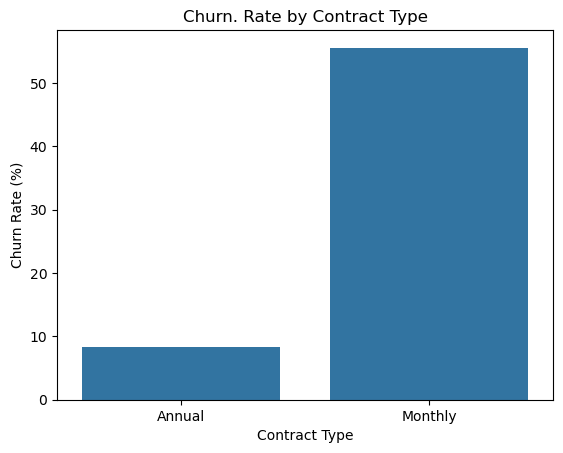

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=contract_churn,x="contract_type",y="churn")

plt.title("Churn. Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

Visual 2 — Churn by Plan Type

In [92]:
plan_churn = df.groupby("plan_type")["churn"].mean().reset_index()
plan_churn["churn"] = plan_churn["churn"] * 100

plan_churn

,plan_type,churn
0,Basic,60.000000
1,Premium,14.285714
2,Standard,22.222222


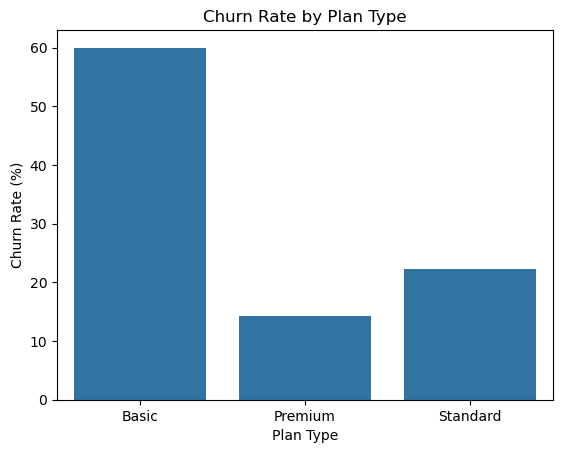

In [93]:
sns.barplot(
    data=plan_churn,
    x="plan_type",
    y="churn"
)

plt.title("Churn Rate by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Churn Rate (%)")
plt.show()

In [94]:
support_churn = df.groupby("has_support")["churn"].mean().reset_index()
support_churn["churn"] = support_churn["churn"] * 100

support_churn

,has_support,churn
0,0,0.000000
1,1,85.714286


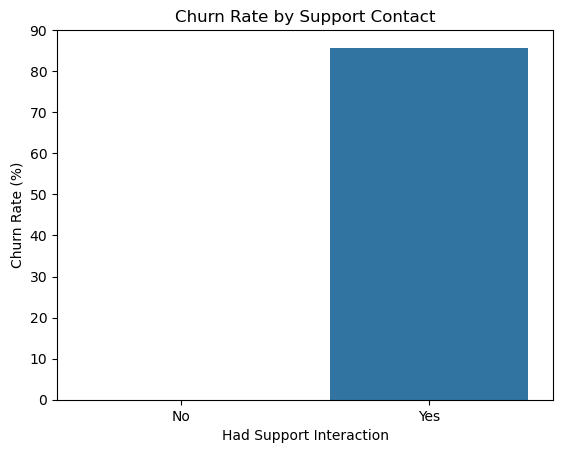

In [95]:
sns.barplot(
    data=support_churn,
    x="has_support",
    y="churn"
)

plt.title("Churn Rate by Support Contact")
plt.xlabel("Had Support Interaction")
plt.ylabel("Churn Rate (%)")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

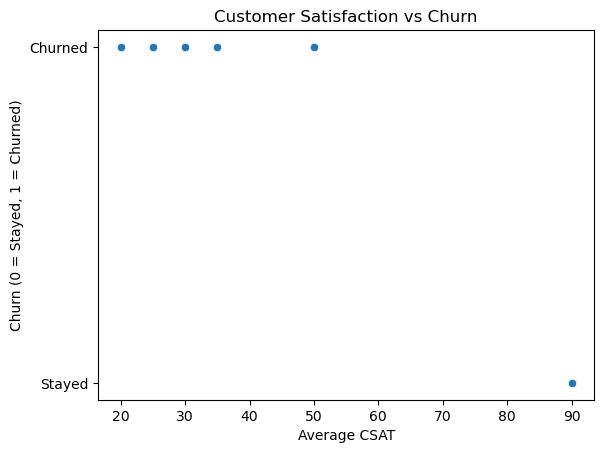

In [96]:
csat_data = df[df["avg_csat"].notna()]

sns.scatterplot(
    data=csat_data,
    x="avg_csat",
    y="churn"
)

plt.title("Customer Satisfaction vs Churn")
plt.xlabel("Average CSAT")
plt.ylabel("Churn (0 = Stayed, 1 = Churned)")
plt.yticks([0, 1], ["Stayed", "Churned"])
plt.show()

In [97]:
escalation_churn = (
    df[df["escalation_count"].notna()]
    .groupby("escalation_count")["churn"]
    .mean()
    .reset_index()
)

escalation_churn["churn"] = escalation_churn["churn"] * 100

escalation_churn

,escalation_count,churn
0,0.0,50.0
1,1.0,100.0


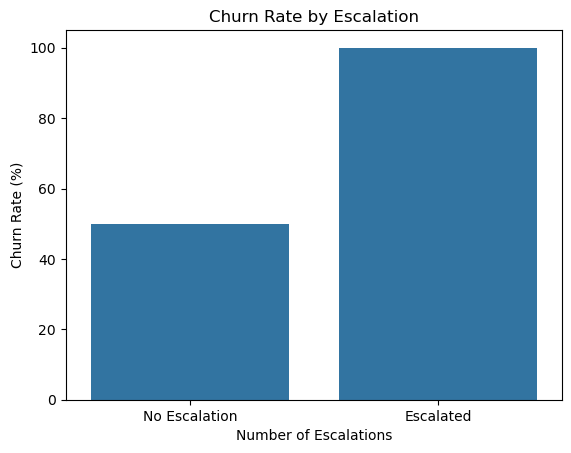

In [98]:
sns.barplot(
    data=escalation_churn,
    x="escalation_count",
    y="churn"
)

plt.title("Churn Rate by Escalation")
plt.xlabel("Number of Escalations")
plt.ylabel("Churn Rate (%)")
plt.xticks([0, 1], ["No Escalation", "Escalated"])
plt.show()

In [99]:
cltv_churn = (
    df.groupby("churn")["cltv"]
    .mean()
    .reset_index()
)

cltv_churn

,churn,cltv
0,0,1016.466667
1,1,341.166667


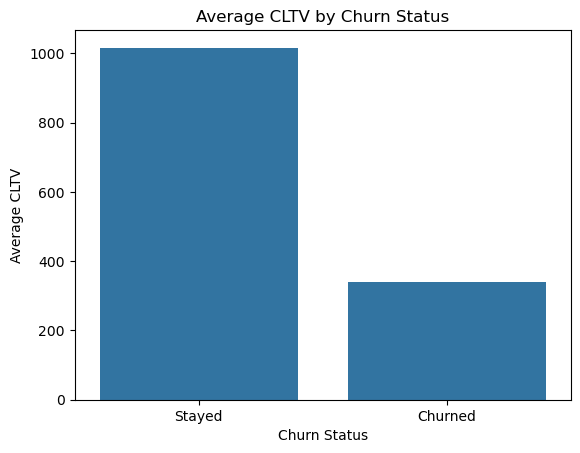

In [100]:
sns.barplot(
    data=cltv_churn,
    x="churn",
    y="cltv"
)

plt.title("Average CLTV by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average CLTV")
plt.xticks([0, 1], ["Stayed", "Churned"])
plt.show()